In [1]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import medfilt 
import scipy.ndimage
from scipy.ndimage import median_filter
import random
import matplotlib.pyplot as plt
import csv

# Normal Median Filtered Histogram 

In [2]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def apply_median_filter(f0_series, kernel_size=5):
    f0_series = np.where(np.isnan(f0_series), 0, f0_series)
    filtered_f0 = medfilt(f0_series, kernel_size = kernel_size)
    filtered_f0[filtered_f0 == 0] = np.nan
    return filtered_f0

def extract_pitch_changes (midi_notes, threshold = 0.5): 
    midi_notes = np.round(midi_notes)
    changes = np.insert(np.diff(midi_notes), 0, 0)
    significant_changes = np.where(abs(changes) >= threshold)[0]
    return midi_notes[significant_changes]

def compute_intervals(midi_notes):
    return np.diff(midi_notes)

def aggregate_pitch_by_window(midi_notes, window_size = 20, method = "median"):
    aggregated = []
    for i in range(0, len(midi_notes), window_size):
        window = midi_notes[i: i + window_size] 
        if len(window) == 0:
            continue
        if method == "mean":
            aggregated.append(np.mean(window))
        else:
            aggregated.append(np.median(window))
    return np.array(aggregated)

def process_f0_file(file_path):
    df = pd.read_csv(file_path, header = None)
    df.columns = ['Time', 'F0', 'Confidence']

    df.loc[df['Confidence'] <= 0.7, "F0"] = np.nan
    
    f0_values = apply_median_filter(df["F0"].values)
    
    valid_f0_values = f0_values[~np.isnan(f0_values)]
    
    midi_notes = f0_to_midi(valid_f0_values)

    midi_notes = aggregate_pitch_by_window(midi_notes, window_size = 20, method = "median")
    
    lower_bound = 41
    upper_bound = 72

    stable_midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]
    
    return stable_midi_notes

def get_interval_histogram(intervals_list, bin_size = 1):
    edges = np.arange(-12, 12 + bin_size, bin_size)
    hist, _ = np.histogram(intervals_list, bins = edges, density = True)
    return hist, edges 

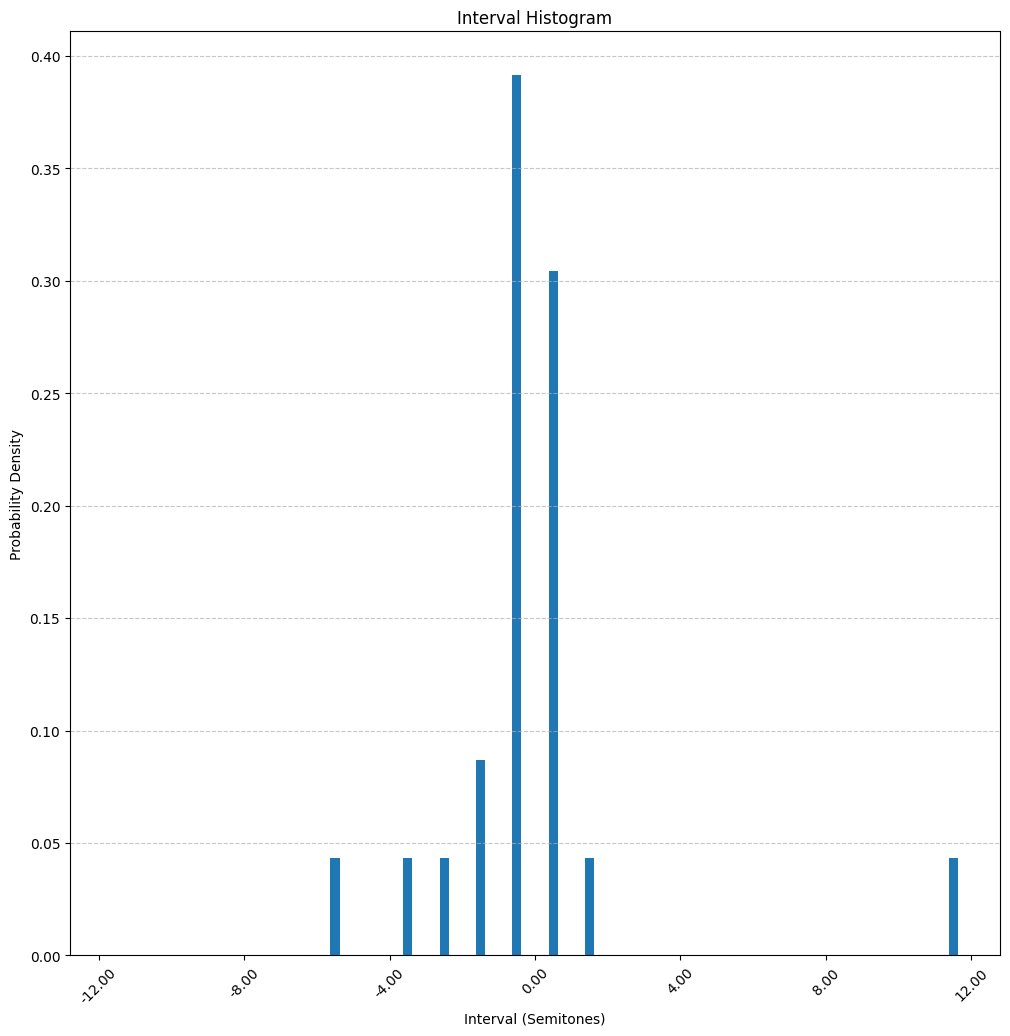

In [3]:
file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0_splitted/적벽가 장승타령 관운장 3(계면)_clip_0-10.csv'

midi_notes = process_f0_file(file_path)

intervals_list = compute_intervals(midi_notes)

hist, edges = get_interval_histogram(intervals_list)

bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 12))
plt.bar(bin_centers, hist, width=0.25, align='center')
plt.xticks(edges[::4], labels=[f"{e:.2f}" for e in edges[::4]], rotation=45)
plt.xlabel("Interval (Semitones)")
plt.ylabel("Probability Density")
plt.title("Interval Histogram")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

/tmp/ipykernel_154491/1782263324.py:38: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154491/1782263324.py:38: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154491/1782263324.py:38: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154491/1782263324.py:38: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154491/1782263324.py:38: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154491/1782263324.py:38: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154491/1782263324.py:38: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.

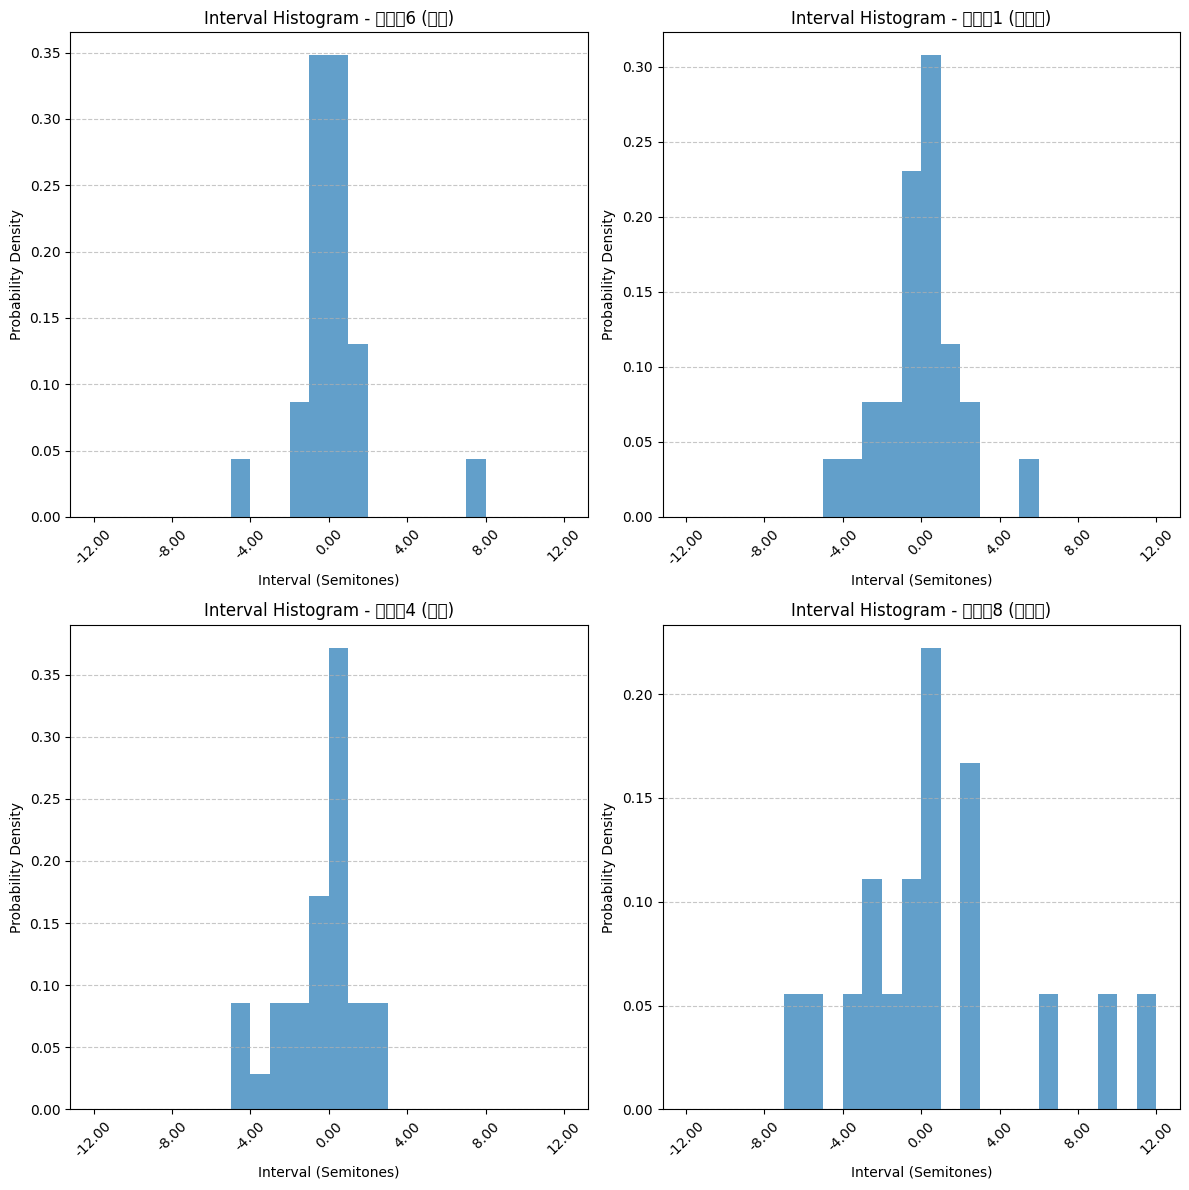

Bhattacharyya Distance: 0.1557
Bhattacharyya Distance: 0.0299
Bhattacharyya Distance: 0.1546
Bhattacharyya Distance: 0.3026


In [4]:
file_paths = [
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0_splitted/적벽가 장승타령 관운장 6(우조)_clip_0-10.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0_splitted/적벽가 장승타령 관운장1(계면)_clip_140-150.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0_splitted/적벽가 장승타령 관운장4(우조)_clip_10-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0_splitted/적벽가 장승타령 관운장8(계면조)_clip_0-10.csv'
]

histograms = []
bin_edges = 0.5

for file_path in file_paths: 
    midi_notes = process_f0_file(file_path)
    intervals_list = compute_intervals(midi_notes)
    hist, edges = get_interval_histogram(intervals_list)
    histograms.append(hist)
    bin_edges = edges

bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 12))

titles = [
    "Interval Histogram - 관운장6 (우조)",
    "Interval Histogram - 관운장1 (계면조)",
    "Interval Histogram - 관운장4 (우조)",
    "Interval Histogram - 관운장8 (계면조)"
]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.bar(bin_centers, histograms[i], width=1, align='center', alpha=0.7)
    plt.xticks(bin_edges[::4], labels=[f"{e:.2f}" for e in bin_edges[::4]], rotation=45)
    plt.xlabel("Interval (Semitones)")
    plt.ylabel("Probability Density")
    plt.title(titles[i])
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

bhattacharyya_coeff = np.sum(np.sqrt(histograms[0] * histograms[1]))
bhattacharyya_distance = -np.log(bhattacharyya_coeff)
print(f"Bhattacharyya Distance: {bhattacharyya_distance:.4f}")

bhattacharyya_coeff2 = np.sum(np.sqrt(histograms[1] * histograms[2]))
bhattacharyya_distance2 = -np.log(bhattacharyya_coeff2)
print(f"Bhattacharyya Distance: {bhattacharyya_distance2:.4f}")

bhattacharyya_coeff3 = np.sum(np.sqrt(histograms[0] * histograms[2]))
bhattacharyya_distance3 = -np.log(bhattacharyya_coeff3)
print(f"Bhattacharyya Distance: {bhattacharyya_distance3:.4f}")

bhattacharyya_coeff4 = np.sum(np.sqrt(histograms[1] * histograms[3]))
bhattacharyya_distance4 = -np.log(bhattacharyya_coeff4)
print(f"Bhattacharyya Distance: {bhattacharyya_distance4:.4f}")

# Morphological Histogram

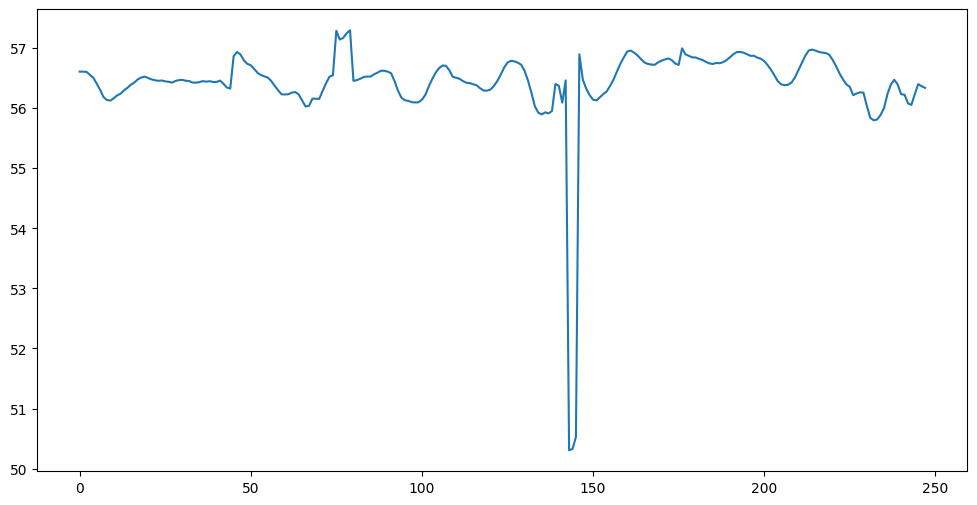

In [5]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/morph_filtered.csv'
df = pd.read_csv(file_path, header = None)

df.columns = ['F0', 'Time']
f0_values = df["F0"].values
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values) 

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

Normalized Pitch Histogram: (array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.03225806, 0.01612903, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.16129032, 0.64516129,
       1.33870968, 0.88709677, 0.83870968, 0.0483871 , 0.03225806,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

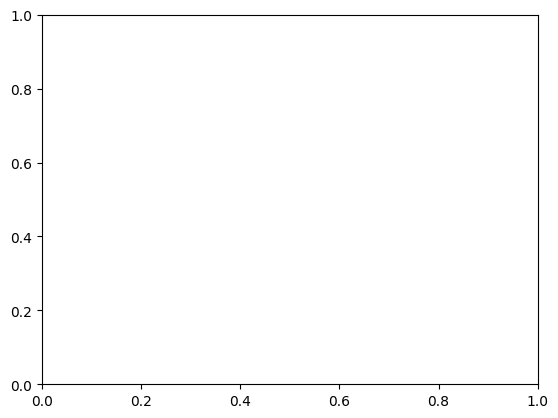

In [6]:
test = get_norm_pitch_histogram(midi_notes)

print("Normalized Pitch Histogram:", test)

plt.bar(range(len(test)), test, tick_label=[f"{-12 + i}" for i in range(25)])
plt.xlabel("Semitone Interval (Relative to Tonic)")
plt.ylabel("Probability Density")
plt.title("Morph-Filtered Pitch Histogram")
plt.show()

# Mask Filtered Histogram

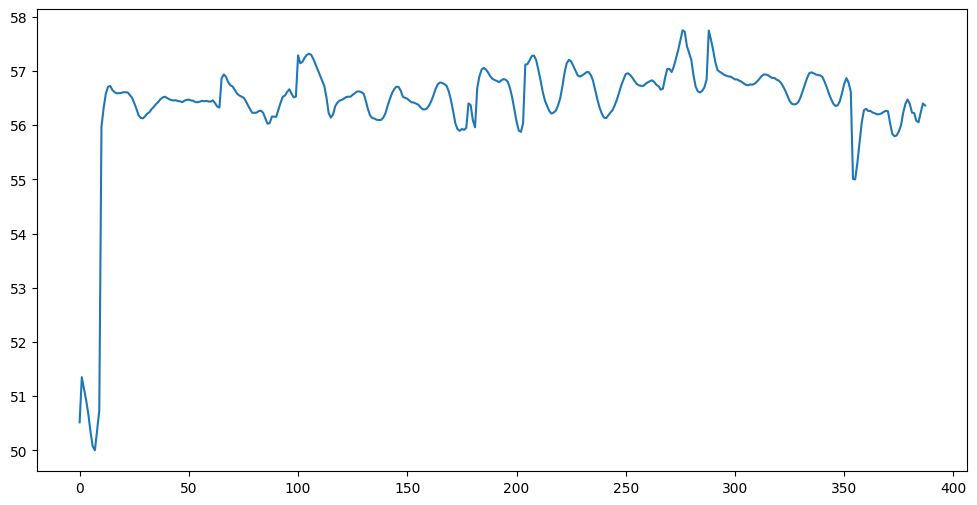

In [9]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/mask_filtered.csv'
df = pd.read_csv(file_path, header = None)

df.columns = ['F0', 'Time']
f0_values = df["F0"].values
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values) 

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

Normalized Pitch Histogram: [0.         0.         0.         0.         0.         0.
 0.02061856 0.00515464 0.         0.         0.00257732 0.04381443
 0.82216495 0.1056701  0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.        ]


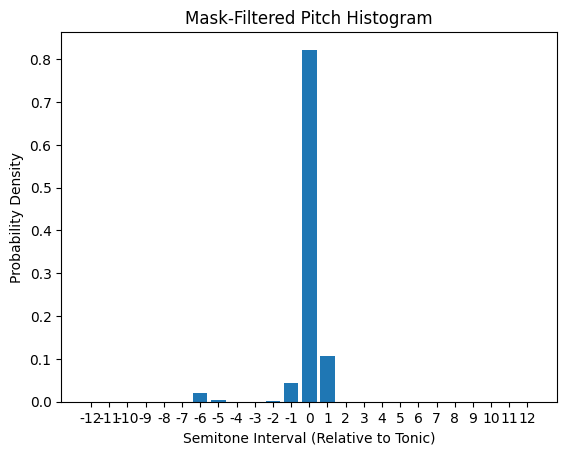

In [ ]:
def get_norm_pitch_histogram(midi_contour):
    edge = [i + (-12.5) for i in range(26)]
    comp = 0
    final_common_midi = 0

    norm_midi = [midi-float(final_common_midi-comp) for midi in midi_contour]
    mono_hist = np.histogram(norm_midi, bins = edge, density=True)
    
    return mono_hist[0]

test = get_norm_pitch_histogram(midi_notes)

print("Normalized Pitch Histogram:", test)

plt.bar(range(len(test)), test, tick_label=[f"{-12 + i}" for i in range(25)])
plt.xlabel("Semitone Interval (Relative to Tonic)")
plt.ylabel("Probability Density")
plt.title("Mask-Filtered Pitch Histogram")
plt.show()


def get_norm_pitch_histogram(midi_notes, bin_size=0.25):

    edges = np.arange(45, 65 + bin_size, bin_size) 
    hist, _ = np.histogram(midi_notes, bins=edges, density=True)
    return hist, edges

test, edges = get_norm_pitch_histogram(midi_notes)